In [ ]:
import lightning
from mlcolvar.utils.io import create_dataset_from_files
from mlcolvar.data import DictModule

# seed
seed_value = 42
lightning.seed_everything(seed_value)

filenames = ["./COLVAR-seldist"]

dataset, df = create_dataset_from_files(
    filenames,
    filter_args={"regex": "dd_"},
    return_dataframe=True,
)

# df.head()
X =df.filter(regex="dd_").values
n_input = X.shape[1]
print(n_input)

Seed set to 42


Class 0 dataframe shape:  (21390, 275)

 - Loaded dataframe (21390, 275): ['time', 'dd_001_146', 'dd_037_139', 'dd_016_155', 'dd_005_131', 'dd_041_111', 'dd_034_145', 'dd_016_037', 'dd_015_137', 'dd_044_158', 'dd_082_139', 'dd_141_161', 'dd_094_141', 'dd_037_090', 'dd_037_070', 'dd_016_111', 'dd_054_111', 'dd_044_139', 'dd_001_053', 'dd_055_165', 'dd_113_141', 'dd_005_113', 'dd_054_094', 'dd_011_106', 'dd_023_102', 'dd_092_141', 'dd_092_161', 'dd_016_102', 'dd_146_161', 'dd_099_131', 'dd_085_146', 'dd_016_092', 'dd_058_120', 'dd_052_125', 'dd_055_146', 'dd_102_141', 'dd_023_041', 'dd_023_034', 'dd_106_146', 'dd_115_133', 'dd_083_113', 'dd_099_147', 'dd_082_106', 'dd_139_152', 'dd_083_115', 'dd_023_083', 'dd_053_075', 'dd_113_129', 'dd_082_146', 'dd_058_158', 'dd_010_092', 'dd_041_066', 'dd_032_094', 'dd_099_125', 'dd_023_092', 'dd_073_125', 'dd_034_066', 'dd_056_131', 'dd_001_016', 'dd_085_115', 'dd_094_165', 'dd_094_158', 'dd_092_129', 'dd_063_094', 'dd_016_066', 'dd_028_099', 'dd_001

In [ ]:
import torch
import numpy as np

# traing Deep-TICA 
# PARAMETERS 
multicanonical    = False        #using a standard reweight (false) or a multicanonical one (true)
temp              = 340.        #reweighting temperature
temp0             = 340.        #simulation temperature (only needed if multicanonical == True)
#------------------

# Calculate inverse temperature
kb=0.008314
beta=1./(kb*temp)
beta0=1./(kb*temp0)

t = df['time'].values # save time
# ene = df['ene'].values.astype(np.float64) # store energy as long double
# bias = df.filter(regex='.bias').values.sum(axis=1) # Load *.bias columns and sum them

# # Compute log-weights for time reweighting
# logweight = beta*bias

# if multicanonical:
#     ene -= np.mean(ene) #first shift energy by its mean value
#     logweight += (beta0-beta)*ene
    
new_len = X.shape[0]
t = t[:new_len]
# logweight = logweight[:new_len]

# Create dataset of time-lagged configurations
from mlcolvar.utils.timelagged import create_timelagged_dataset
from torch.utils.data import Subset,random_split

# define time lag
lag_time = 1  # timestep = 0.2ns * 25 * 1 = 5ns
batch_size        = 1024 * 256

# create dataset
dataset = create_timelagged_dataset(X,
                                    t=t,
                                    lag_time=lag_time,
                                    logweights=None,           
                                    progress_bar=True)        

dataset


100%|██████████| 21388/21388 [00:00<00:00, 107346.53it/s]
/data/zzt/z233/0-program/mlcolvar-1.2.2/mlcolvar/utils/timelagged.py:186: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x_t = torch.stack(x_t) if type(x) == torch.Tensor else torch.Tensor(x_t)


DictDataset( "data": [42776, 273], "data_lag": [42776, 273], "weights": [42776], "weights_lag": [42776] )

In [ ]:
# create datamodule (split train valid)
from mlcolvar.data import DictModule

datamodule = DictModule(dataset,
                        lengths=[0.8,0.2],  # 80% train, 20% valid
                        random_split=False,
                        batch_size=batch_size,
                        shuffle=False)  # shuffle=False for reproducibility
datamodule

n_components = 2
patience     = 10
epochs       = 1000
log_every    = 10
#------------------------------------------------------------------------------
from mlcolvar.cvs import DeepTICA

# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

nn_layers = [n_input, 64, 64, n_components]
options = { 'nn':{'activation': 'tanh'}}  # activation function and dropout rate
model = DeepTICA(nn_layers, options=options)
model.to(device)
model

# Training the model
import lightning
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from mlcolvar.utils.trainer import MetricsCallback

metrics =MetricsCallback()
early_stopping = EarlyStopping(monitor="valid_loss",
                               min_delta=0.0,
                               patience=patience,
                               )

trainer = lightning.Trainer(callbacks=[metrics, early_stopping],
                            # max_epochs=epochs,
                            max_epochs=None,  # No max epochs
                            logger=True,  # No logger
                            enable_checkpointing=False)

trainer.fit( model, datamodule)


/data/zzt/z233/0-program/mlcolvar-1.2.2/mlcolvar/data/datamodule.py:133: UserWarning: A torch.generator was provided but it is not used with random_split=False
  warnings.warn(
/data/zzt/z233/miniconda3/envs/vk/lib/python3.10/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/data/zzt/z233/miniconda3/envs/vk/lib/python3.10/site-packages/torch/cuda/__init__.py:1036: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  r = torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/data/zzt/z233/miniconda3/envs/vk/lib/python3.10/site-packages/ligh

/data/zzt/z233/miniconda3/envs/vk/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 258: 100%|██████████| 1/1 [00:00<00:00, 10.91it/s, v_num=14]


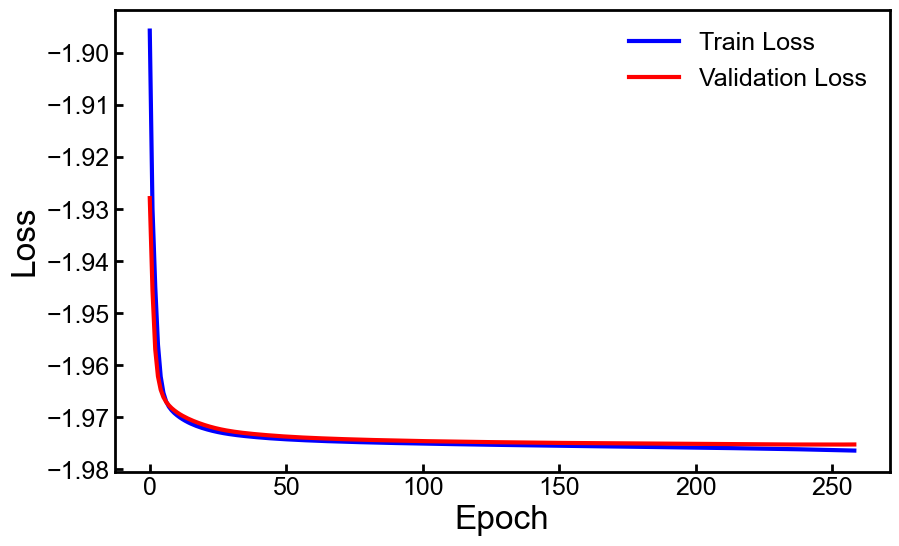

Writing data to loss.csv...
Successfully saved data to cln025_loss_273.csv


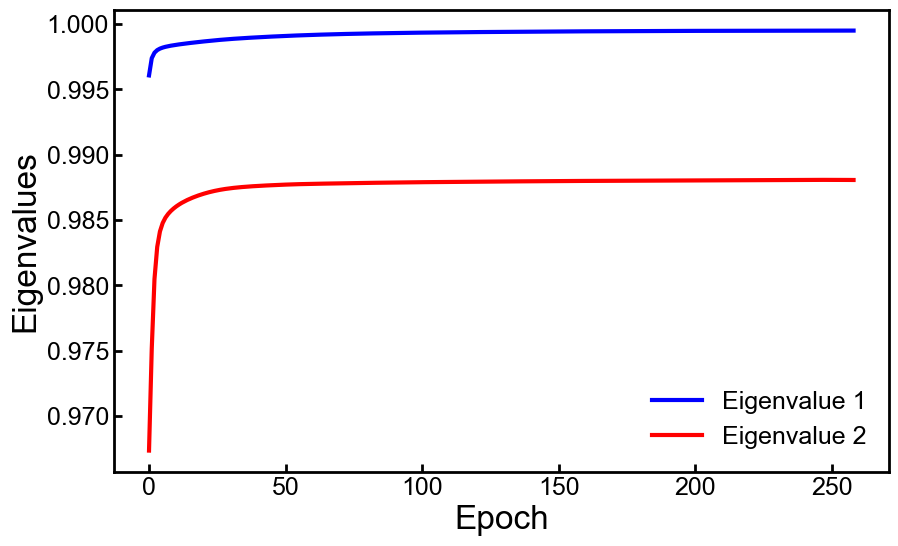

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare Data
train_loss = metrics.metrics['train_loss']
valid_loss = metrics.metrics['valid_loss']
valid_eigval_1 = metrics.metrics['valid_eigval_1']
valid_eigval_2 = metrics.metrics['valid_eigval_2']
epochs = list(range(len(train_loss)))

# 2. Save to CSV
print("Writing to CSV file...")
df_metrics = pd.DataFrame({
    'Epoch': epochs,
    'Train_Loss': train_loss,
    'Valid_Loss': valid_loss,
    'Valid_Eigval_1': valid_eigval_1,
    'Valid_Eigval_2': valid_eigval_2
})
df_metrics.to_csv('cln025_loss_273.csv', index=False)
print("Data saved to cln025_loss_273.csv")


# 3. Define Plotting Function
def plot_curve(x_data, y_data_dict, ylabel, filename):
    plt.figure(figsize=(10, 6))
    
    colors = ['blue', 'red']
    for i, (label, y_data) in enumerate(y_data_dict.items()):
        color = colors[i % len(colors)]
        plt.plot(x_data, y_data, label=label, color=color, linewidth=3)

    # Style settings: ticks inward
    plt.tick_params(axis='both', direction='in', length=6, width=2, labelsize=18)
    
    # Bold border
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)

    # Labels and Legend
    plt.xlabel('Epoch', fontsize=24)
    plt.ylabel(ylabel, fontsize=24)
    plt.legend(fontsize=18, frameon=False)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=800, bbox_inches='tight')
    plt.show()


# 4. Plot Figures
# Plot Loss Curve
plot_curve(
    epochs, 
    {'Train Loss': train_loss, 'Validation Loss': valid_loss}, 
    'Loss', 
    'cln025_loss_273.png'
)

# Plot Eigenvalues Curve
plot_curve(
    epochs, 
    {'Eigenvalue 1': valid_eigval_1, 'Eigenvalue 2': valid_eigval_2}, 
    'Eigenvalues', 
    'cln025_eigenvalues_273.png'
)

In [ ]:
# Normalization
from mlcolvar.core.transform import Normalization
from mlcolvar.core.transform.utils import Statistics

#X = dataset[:]['data']
with torch.no_grad():
    model.postprocessing = None # reset
    s = model(torch.Tensor(X))

norm =  Normalization(n_components, mode='min_max', stats = Statistics(s) )
model.postprocessing = norm

# save the model
dummy_input = torch.randn(batch_size, n_input)
traced_model = torch.jit.trace(model, dummy_input)
traced_model.save("model-dwt.ptc")

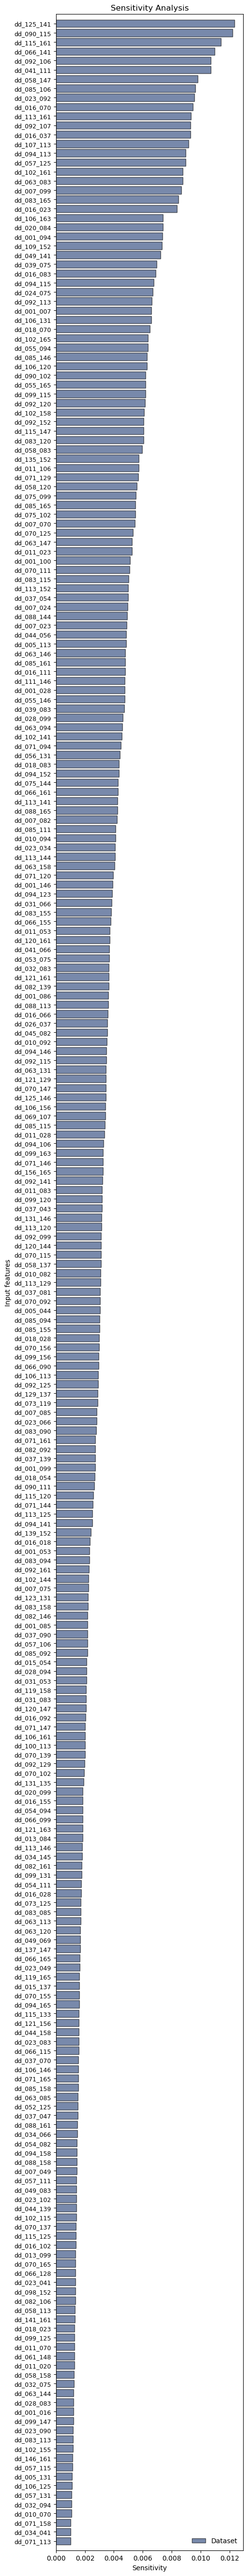

In [38]:
# sensitivity_analysis
from mlcolvar.explain import sensitivity_analysis, plot_sensitivity
import pandas as pd

feature_names = df.filter(regex="dd_").columns.tolist()

results = sensitivity_analysis(model,               
                               dataset, 
                            #    std=std,
                               metric="mean_abs_val",   # metric to use to compute the sensitivity per feature (e.g. mean absolute value or root mean square)
                               feature_names=feature_names,      # by default, they will be taken from `dataset.feature_names` 
                               per_class=False,         # whether to do per-class statistics
                               plot_mode=None,
                               )          # plot mode (see below) 

plot_sensitivity(results, mode='barh', per_class=False, max_features=273)
plt.show()
# print(results)

In [ ]:
# Extract results
feature_names_list = results['feature_names']
sensitivity_list = results['sensitivity']
gradients_list = results['gradients']

# Verify list lengths
# print(f"Feature names length: {len(feature_names_list)}")
print(f"Sensitivity length: {len(sensitivity_list)}")
print(f"Gradients length: {len(gradients_list)}")

sensitivity_df = pd.DataFrame({
    'sensitivity_value': sensitivity_list,
   
})
sensitivity_df.to_csv('sensitivity.csv', index=False)

In [ ]:
# Select top 210 features from sensitivity analysis for retraining
from mlcolvar.data import DictDataset

n_features = 210
relevant_features = results['feature_names'][-n_features:]

Y = df[relevant_features].values

# Create time-lagged dataset
dataset_210 = create_timelagged_dataset(
    Y,
    t=t,
    lag_time=lag_time,
    logweights=None,      # Log weights (None for unbiased)
    progress_bar=True     # Show progress bar
)

dataset_210

# Create data module (Train/Validation split)
from mlcolvar.data import DictModule

datamodule = DictModule(
    dataset_210,
    lengths=[0.8, 0.2],   # Split: 80% train, 20% validation
    random_split=False,
    batch_size=batch_size,
    shuffle=False         # Disable shuffle for reproducibility
)

datamodule

100%|██████████| 21388/21388 [00:00<00:00, 113143.25it/s]


DictDataset( "data": [42776, 210], "data_lag": [42776, 210], "weights": [42776], "weights_lag": [42776] )

In [ ]:
n_components = 2
patience     = 10
epochs       = 1000
log_every    = 10
#------------------------------------------------------------------------------
from mlcolvar.cvs import DeepTICA

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

nn_layers = [210, 64, 64, n_components]
options = { 'nn':{'activation': 'tanh'}}  # activation function and dropout rate
model = DeepTICA(nn_layers, options=options)
model.to(device)
model


# Training the model
import lightning
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from mlcolvar.utils.trainer import MetricsCallback

metrics =MetricsCallback()
early_stopping = EarlyStopping(monitor="valid_loss",
                               min_delta=0.0,
                               patience=patience,
                               )

trainer = lightning.Trainer(callbacks=[metrics, early_stopping],
                            # max_epochs=epochs,
                            max_epochs=None,  # No max epochs
                            logger=True,  # No logger
                            enable_checkpointing=False)

trainer.fit( model, datamodule)


Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/data/zzt/z233/miniconda3/envs/vk/lib/python3.10/site-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name    | Type                  | Params | Mode  | In sizes | Out sizes
---------------------------------------------------------------------------------
0 | loss_fn | ReduceEigenvaluesLoss | 0      | train | ?        | ?        
1 | norm_in | Normalization         | 0      | train | [1, 210] | [1, 210] 
2 | nn      | FeedForward           | 17.8 K | train | [1, 210] | [1, 2]   
3 | tica    | TICA                  | 0      | train | [1, 2]   | [1, 2]   
---------------------------------------------------------------------------------
17.8 K    Trainable params
0         Non-trainable params
17.8 K    Total params
0.071     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


/data/zzt/z233/miniconda3/envs/vk/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 195: 100%|██████████| 1/1 [00:00<00:00, 11.38it/s, v_num=6]


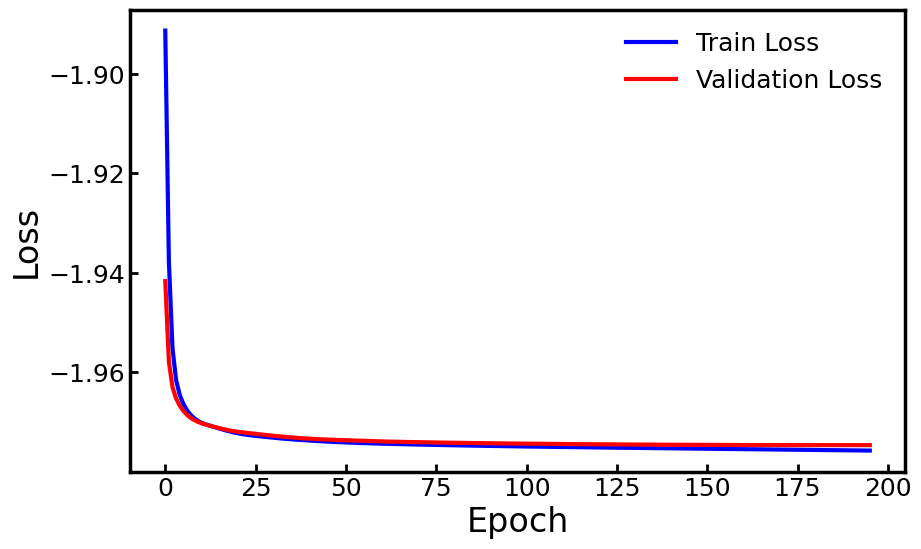

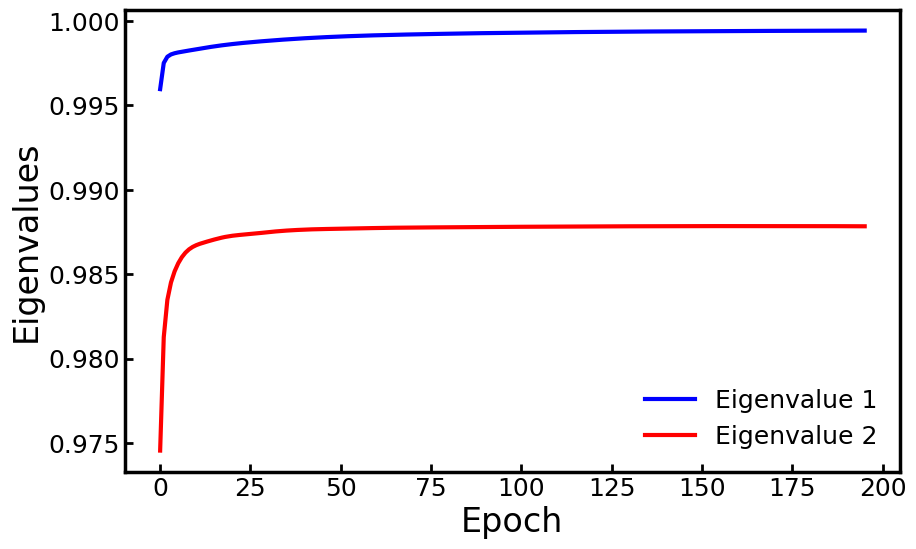

In [ ]:
import matplotlib.pyplot as plt


# Part 1: Plot Loss Function
# ---------------------------------

# Extract loss metrics
train_loss = metrics.metrics['train_loss']
valid_loss = metrics.metrics['valid_loss']
epochs = range(len(train_loss))

# Initialize figure
plt.figure(figsize=(10, 6))

# Plot data
plt.plot(epochs, train_loss, label='Train Loss', color='blue', linewidth=3)
plt.plot(epochs, valid_loss, label='Validation Loss', color='red', linewidth=3)

# Style setup
plt.tick_params(axis='both', direction='in', length=6, width=2, labelsize=18)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Labels and Legend
plt.xlabel('Epoch', fontsize=24)
plt.ylabel('Loss', fontsize=24)
plt.legend(fontsize=18, frameon=False)

# Save and show
plt.savefig('loss-dwt_210.png', dpi=600, bbox_inches='tight')
plt.show()



# Part 2: Plot Eigenvalues
# ---------------------------------

# Extract eigenvalues
eigvals = [
    metrics.metrics['valid_eigval_1'],
    metrics.metrics['valid_eigval_2']
]
epochs_eig = range(len(eigvals[0]))

# Initialize figure
plt.figure(figsize=(10, 6))

# Plot each eigenvalue
colors = ['blue', 'red']
for i, eigval in enumerate(eigvals):
    plt.plot(epochs_eig, eigval, label=f'Eigenvalue {i+1}', color=colors[i], linewidth=3)

# Style setup
plt.tick_params(axis='both', direction='in', length=6, width=2, labelsize=18)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Labels and Legend
plt.xlabel('Epoch', fontsize=24)
plt.ylabel('Eigenvalues', fontsize=24)
plt.legend(fontsize=18, frameon=False)

# Save and show
plt.savefig('eigenvalues-dwt_210.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
# Apply normalization
from mlcolvar.core.transform import Normalization
from mlcolvar.core.transform.utils import Statistics

with torch.no_grad():
    model.postprocessing = None # Reset
    s = model(torch.Tensor(Y))

norm = Normalization(n_components, mode='min_max', stats=Statistics(s))
model.postprocessing = norm

# Save model
dummy_input = torch.randn(batch_size, 210)  # Match input shape

# Trace and save
traced_model = torch.jit.trace(model, dummy_input)
traced_model.save("model-dwt_210.ptc")

# Print summary
print("DWT features (273):", df.columns.tolist())
print("Selected features after sensitivity analysis (210):", relevant_features.tolist())

# Write feature names to file
with open("list.dat", "w") as f:
    # Write feature list header
    f.write("DWT features (273):\n")
    # Write all 273 features
    for col_name in df.columns.tolist():
        f.write(col_name + ",")
    
    # Add separator
    f.write("\n")
    
    # Write selected feature list header
    f.write("Selected features after sensitivity analysis (210):\n")
    # Write 210 selected features
    for feature in relevant_features.tolist():
        f.write(feature + ",")

print("File 'list.dat' created successfully.")